#### why fast & slow (spindle_00)

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_00'))

d:\mynew\demo_all


#### scale2 0  c2tsc 0 a 8-10 (raw_data_a_scan)

In [29]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10                    # 每个参数值运行 10 次
c2tsc = 0.0                    # 固定 c2tsc = 0
scale2 = 0.0                   # 固定 scale2 = 0

# a 值范围：8 到 10，取 10 个数
a_list = np.linspace(8.4, 8.9, 15)

print("="*60)
print("参数扫描设置")
print("="*60)
print(f"a 值列表: {a_list}")
print(f"c2tsc: {c2tsc}")
print(f"scale2: {scale2}")
print(f"每个参数 seed 数: {n_runs}")
print(f"总运行次数: {len(a_list) * n_runs}")

# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_a_scan"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件 ==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 运行任务 ==========
total_tasks = len(a_list) * n_runs
completed = 0
skipped = 0

for a_val in a_list:
    for seed in range(1, n_runs + 1):
        # 生成文件名
        filename = f"a_{a_val:.4f}_c2tsc_{c2tsc:.4f}_scale2_{scale2:.6f}_seed_{seed}.npy"
        save_path = os.path.join(DATA_DIR, filename)
        
        # 如果文件已存在，跳过
        if filename in existing_files:
            print(f"跳过: {filename}")
            skipped += 1
            continue
        
        # 加载默认参数并修改
        params = dp.loadDefaultParams(seed)
        
        # 修改 a 值
        params["a"] = a_val
        
        # 根据 a 值修改丘脑电压阈值
        params["VT_t"] = 26 - a_val
        params["VT_r"] = 23 - a_val
        params["VB_t"] = 15 - a_val
        params["VB_r"] = 15 - a_val
        
        # 固定 c2tsc 和 scale2
        params["c2tsc"] = c2tsc
        params["scale2"] = scale2
        
        # 运行模型
        try:
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        except Exception as e:
            print(f"失败: {filename}, 错误: {e}")
            continue
        
        # 保存 raw 信号
        np.save(save_path, {
            "t": t, "V_e": V_e, "V_i": V_i, 
            "Q_e": Q_e, "Q_i": Q_i, 
            "V_t": V_t, "V_r": V_r, 
            "Q_t": Q_t, "Q_r": Q_r,
            "a": a_val,
            "c2tsc": c2tsc,
            "scale2": scale2,
            "seed": seed
        })
        
        completed += 1
        if completed % 10 == 0:
            print(f"进度: {completed}/{total_tasks - skipped}")

print("\n" + "="*60)
print("完成统计")
print("="*60)
print(f"总任务数: {total_tasks}")
print(f"新运行: {completed}")
print(f"跳过已存在: {skipped}")
print(f"数据保存在: {DATA_DIR}")

# ========== 显示生成的文件 ==========
print("\n生成的文件统计:")
for a_val in a_list:
    count = 0
    for f in os.listdir(DATA_DIR):
        if f.endswith(".npy") and f"a_{a_val:.4f}" in f:
            count += 1
    print(f"  a={a_val:.4f}: {count} 个文件")

参数扫描设置
a 值列表: [8.4        8.43571429 8.47142857 8.50714286 8.54285714 8.57857143
 8.61428571 8.65       8.68571429 8.72142857 8.75714286 8.79285714
 8.82857143 8.86428571 8.9       ]
c2tsc: 0.0
scale2: 0.0
每个参数 seed 数: 10
总运行次数: 150

已存在 150 个文件
进度: 10/150
进度: 20/150
进度: 30/150
进度: 40/150
进度: 50/150
进度: 60/150
进度: 70/150
进度: 80/150
进度: 90/150
进度: 100/150
进度: 110/150
进度: 120/150
进度: 130/150
进度: 140/150
进度: 150/150

完成统计
总任务数: 150
新运行: 150
跳过已存在: 0
数据保存在: data/raw_data_a_scan

生成的文件统计:
  a=8.4000: 10 个文件
  a=8.4357: 10 个文件
  a=8.4714: 10 个文件
  a=8.5071: 10 个文件
  a=8.5429: 10 个文件
  a=8.5786: 10 个文件
  a=8.6143: 10 个文件
  a=8.6500: 10 个文件
  a=8.6857: 10 个文件
  a=8.7214: 10 个文件
  a=8.7571: 10 个文件
  a=8.7929: 10 个文件
  a=8.8286: 10 个文件
  a=8.8643: 10 个文件
  a=8.9000: 10 个文件


In [30]:
import numpy as np
import pandas as pd
import yasa
import glob
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a_scan"
OUTPUT_CSV = "data/analysis_data/spindles_a_scan.csv"

# ========== 读取所有文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# ========== 检测纺锤波并生成 CSV ==========
all_spindles = []

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    a_val = float(parts[1])
    c2tsc = float(parts[3])
    scale2 = float(parts[5])
    seed = int(parts[7])
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    
    # 检测快纺锤波 (12-16 Hz)
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    if sp_fast is not None:
        df_fast = sp_fast.summary()
        for _, row in df_fast.iterrows():
            all_spindles.append({
                "a": a_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "fast",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })
    
    # 检测慢纺锤波 (8-12 Hz)
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    if sp_slow is not None:
        df_slow = sp_slow.summary()
        for _, row in df_slow.iterrows():
            all_spindles.append({
                "a": a_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "slow",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })

# 保存 CSV
df_spindles = pd.DataFrame(all_spindles)
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df_spindles.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(df_spindles)} 个纺锤波")
print(f"快纺锤波: {len(df_spindles[df_spindles['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_spindles[df_spindles['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印各 a 值的统计
print("\n各 a 值统计:")
a_values = sorted(df_spindles['a'].unique())
for a_val in a_values:
    subset = df_spindles[df_spindles['a'] == a_val]
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    print(f"  a={a_val:.3f}: fast={fast_count}, slow={slow_count}, total={len(subset)}")

找到 300 个文件


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
02-Jul-26 22:06:29 | WARNING | No spindle were found in channel CHAN000.
02-


总共检测到 3966 个纺锤波
快纺锤波: 1867
慢纺锤波: 2099
CSV 已保存: data/analysis_data/spindles_a_scan.csv

各 a 值统计:
  a=8.000: fast=14, slow=98, total=112
  a=8.222: fast=41, slow=93, total=134
  a=8.400: fast=35, slow=95, total=130
  a=8.436: fast=35, slow=103, total=138
  a=8.444: fast=37, slow=63, total=100
  a=8.471: fast=48, slow=85, total=133
  a=8.507: fast=48, slow=101, total=149
  a=8.543: fast=57, slow=85, total=142
  a=8.579: fast=58, slow=105, total=163
  a=8.614: fast=47, slow=89, total=136
  a=8.650: fast=54, slow=94, total=148
  a=8.667: fast=54, slow=86, total=140
  a=8.686: fast=72, slow=110, total=182
  a=8.721: fast=61, slow=84, total=145
  a=8.757: fast=63, slow=92, total=155
  a=8.793: fast=69, slow=87, total=156
  a=8.829: fast=58, slow=80, total=138
  a=8.864: fast=59, slow=103, total=162
  a=8.889: fast=67, slow=87, total=154
  a=8.900: fast=62, slow=101, total=163
  a=9.100: fast=80, slow=50, total=130
  a=9.111: fast=99, slow=58, total=157
  a=9.200: fast=110, slow=59, total=169

读取 3966 个纺锤波

各 a 值纺锤波数量:
  a=8.000: fast=14, slow=94
  a=8.222: fast=39, slow=87
  a=8.400: fast=33, slow=87
  a=8.436: fast=33, slow=95
  a=8.444: fast=35, slow=59
  a=8.471: fast=43, slow=76
  a=8.507: fast=44, slow=95
  a=8.543: fast=56, slow=78
  a=8.579: fast=56, slow=97
  a=8.614: fast=45, slow=82
  a=8.650: fast=51, slow=84
  a=8.667: fast=52, slow=82
  a=8.686: fast=65, slow=105
  a=8.721: fast=55, slow=77
  a=8.757: fast=60, slow=89
  a=8.793: fast=66, slow=81
  a=8.829: fast=53, slow=78
  a=8.864: fast=54, slow=93
  a=8.889: fast=62, slow=81
  a=8.900: fast=55, slow=91
  a=9.100: fast=74, slow=45
  a=9.111: fast=93, slow=56
  a=9.200: fast=103, slow=54
  a=9.300: fast=74, slow=30
  a=9.333: fast=65, slow=23
  a=9.400: fast=88, slow=10
  a=9.500: fast=99, slow=15
  a=9.556: fast=106, slow=7
  a=9.778: fast=60, slow=0
  a=10.000: fast=8, slow=0




In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
window_before = 1.0
window_after = 1.0
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_a_scan.csv"
DATA_DIR = "data/raw_data_a_scan"

# ========== 2. 读取 CSV ==========
df_spindles = pd.read_csv(CSV_PATH)
print(f"读取 {len(df_spindles)} 个纺锤波")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    a_val = float(parts[1])
    seed = int(parts[7])
    file_map[(a_val, seed)] = file_path

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

# 按 a 值分组
a_values = sorted(df_spindles['a'].unique())
a_groups = {}
for a_val in a_values:
    a_groups[a_val] = {"fast": [], "slow": []}

for _, row in df_spindles.iterrows():
    a_val = row["a"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (a_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        a_groups[a_val][spindle_type].append(seg)

# ========== 5. 计算均值和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

print("\n各 a 值纺锤波数量:")
for a_val in a_values:
    fast_count = len(a_groups[a_val]["fast"])
    slow_count = len(a_groups[a_val]["slow"])
    print(f"  a={a_val:.3f}: fast={fast_count}, slow={slow_count}")

# ========== 6. 所有 a 值画在一张大图里 ==========
n_a = len(a_values)
fig, axes = plt.subplots(n_a, 3, figsize=(18, 3.5 * n_a))

if n_a == 1:
    axes = axes.reshape(1, -1)

for row_idx, a_val in enumerate(a_values):
    fast_segs = a_groups[a_val]["fast"]
    slow_segs = a_groups[a_val]["slow"]
    
    fast_mean, fast_sem = compute_mean_sem(fast_segs)
    slow_mean, slow_sem = compute_mean_sem(slow_segs)
    
    # ===== 列1：快纺锤波 =====
    ax = axes[row_idx, 0]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Fast (n={len(fast_segs)})', fontsize=10)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title('Fast (n=0)', fontsize=10)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.5)
    ax.set_ylabel(f'a={a_val:.3f}', fontsize=9, rotation=0, labelpad=20)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == n_a - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    
    # ===== 列2：慢纺锤波 =====
    ax = axes[row_idx, 1]
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Slow (n={len(slow_segs)})', fontsize=10)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title('Slow (n=0)', fontsize=10)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.5)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == n_a - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    
    # ===== 列3：快慢叠加 =====
    ax = axes[row_idx, 2]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'orange', linewidth=1.5, label='Fast')
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='orange', alpha=0.2)
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'steelblue', linewidth=1.5, label='Slow')
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='steelblue', alpha=0.2)
    if fast_mean is None and slow_mean is None:
        ax.text(0, 0, 'No data', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.5)
    ax.set_title('Fast vs Slow', fontsize=10)
    ax.set_ylim(-5, 10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    if row_idx == n_a - 1:
        ax.set_xlabel('Time (s)', fontsize=10)

# 添加整体标题
fig.suptitle('Average TC Neuron Activity (V_t) Locked to Spindle Peak', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### a=8.400 wavelet power

a=8.4 纺锤波总数: 130
  快纺锤波: 35
  慢纺锤波: 95
找到 10 个匹配的文件
快纺锤波片段: 30
慢纺锤波片段: 83

fast_t 范围: [-1.500, 1.500]
slow_t 范围: [-1.500, 1.500]


d:\anaconda\envs\neurolib_old\lib\site-packages\ipykernel_launcher.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


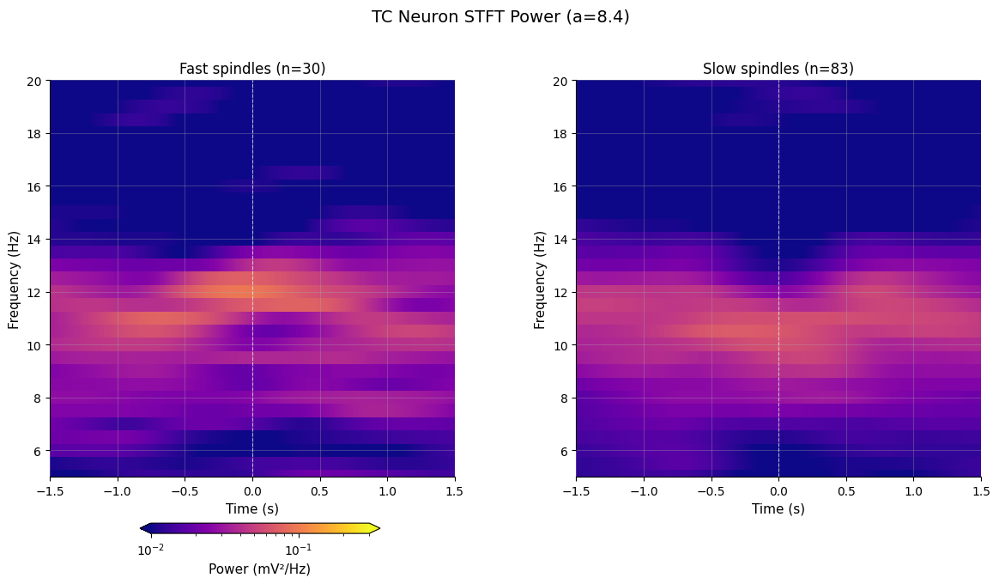


统计摘要 (a=8.4)
快纺锤波: 30 个片段
慢纺锤波: 83 个片段


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import yasa
from yasa import stft_power
import matplotlib as mpl
import seaborn as sns

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
window_before = 1.5
window_after = 1.5
window_samples = int((window_before + window_after) * sf)

TARGET_A = 8.400
DATA_DIR = "data/raw_data_a_scan"
CSV_PATH = "data/analysis_data/spindles_a_scan.csv"

# STFT 参数
window = 2.0   # 秒
step = 0.2     # 秒
freqs_bounds = (0.5, 30.0)
vmin = 0.01
vmax = 0.3
CMAP = "plasma"
SXX_EPS = 1.1e-3

# ========== 2. 读取 CSV ==========
df = pd.read_csv(CSV_PATH)
df_filtered = df[df['a'] == TARGET_A].copy()
print(f"a={TARGET_A} 纺锤波总数: {len(df_filtered)}")
print(f"  快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"  慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

if len(df_filtered) == 0:
    print(f"错误: 没有找到 a={TARGET_A} 的纺锤波数据！")
    print(f"可用的 a 值: {sorted(df['a'].unique())}")
    exit()

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    a_val = float(parts[1])
    seed = int(parts[7])
    if a_val == TARGET_A:
        file_map[(a_val, seed)] = file_path

print(f"找到 {len(file_map)} 个匹配的文件")

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

fast_segments = []
slow_segments = []

for _, row in df_filtered.iterrows():
    a_val = row["a"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (a_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        if spindle_type == 'fast':
            fast_segments.append(seg)
        else:
            slow_segments.append(seg)

print(f"快纺锤波片段: {len(fast_segments)}")
print(f"慢纺锤波片段: {len(slow_segments)}")

if len(fast_segments) == 0 and len(slow_segments) == 0:
    print("错误: 没有提取到任何纺锤波片段！")
    exit()

# ========== 5. 计算平均 STFT 功率 ==========
def compute_average_stft(segments, sf, window, step, freqs_bounds):
    if len(segments) == 0:
        return None, None, None
    
    all_power = []
    common_f = None
    common_t = None
    
    for seg in segments:
        # 创建时间序列，时间轴以 0 为中心
        t_axis = np.linspace(-window_before, window_after, len(seg))
        seg_series = pd.Series(seg, index=t_axis)
        
        f, t, Sxx = stft_power(
            seg_series,
            sf,
            window=window,
            step=step,
            band=freqs_bounds,
            norm=True,
            interp=True,
        )
        
        # 关键：将 STFT 的时间轴重新对齐到 0 为中心
        # t 是相对于片段起始的时间，需要减去片段起始时刻（-window_before）
        # 这样 0 时刻就对应纺锤波峰值
        t_aligned = t - window_before
        
        if common_f is None:
            common_f = f
            common_t = t_aligned
        
        all_power.append(Sxx)
    
    if len(all_power) == 0:
        return None, None, None
    
    # 裁剪到相同时间长度
    min_t_len = min([p.shape[1] for p in all_power])
    all_power_cropped = [p[:, :min_t_len] for p in all_power]
    
    all_power_array = np.array(all_power_cropped)
    mean_power = np.mean(all_power_array, axis=0)
    
    t_axis = common_t[:min_t_len]
    
    return common_f, t_axis, mean_power

fast_f, fast_t, fast_power = compute_average_stft(fast_segments, sf, window, step, freqs_bounds)
slow_f, slow_t, slow_power = compute_average_stft(slow_segments, sf, window, step, freqs_bounds)

print(f"\nfast_t 范围: [{fast_t[0]:.3f}, {fast_t[-1]:.3f}]")
print(f"slow_t 范围: [{slow_t[0]:.3f}, {slow_t[-1]:.3f}]")

# ========== 6. 画图 ==========
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(nrows=1, ncols=2)
gs.update(wspace=0.3, hspace=0.3)

# 左图：快纺锤波
ax = fig.add_subplot(gs[0, 0])
if fast_power is not None and fast_power.size > 0:
    im = ax.pcolormesh(
        fast_t,
        fast_f,
        fast_power + SXX_EPS,
        cmap=CMAP,
        rasterized=True,
        norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.set_title(f'Fast spindles (n={len(fast_segments)})', fontsize=12)
else:
    ax.text(0, 0, 'No fast spindles', ha='center', va='center')
    ax.set_title('Fast spindles', fontsize=12)

ax.axvline(x=0, color='white', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Frequency (Hz)', fontsize=11)
ax.set_ylim(5, 20)
ax.set_xlim(-window_before, window_after)
ax.grid(True, alpha=0.3)
sns.despine(trim=True, ax=ax)

# 右图：慢纺锤波
ax = fig.add_subplot(gs[0, 1])
if slow_power is not None and slow_power.size > 0:
    im = ax.pcolormesh(
        slow_t,
        slow_f,
        slow_power + SXX_EPS,
        cmap=CMAP,
        rasterized=True,
        norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.set_title(f'Slow spindles (n={len(slow_segments)})', fontsize=12)
else:
    ax.text(0, 0, 'No slow spindles', ha='center', va='center')
    ax.set_title('Slow spindles', fontsize=12)

ax.axvline(x=0, color='white', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Frequency (Hz)', fontsize=11)
ax.set_ylim(5, 20)
ax.set_xlim(-window_before, window_after)
ax.grid(True, alpha=0.3)
sns.despine(trim=True, ax=ax)

# 颜色条
#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])
cbar_ax = fig.add_axes([0.2, 0.0, 0.2, 0.02])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax,
    cmap=plt.get_cmap(CMAP),
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    orientation="horizontal",
    extend="both",
)
cbar.set_label("Power (mV²/Hz)", fontsize=11)

plt.suptitle(f'TC Neuron STFT Power (a={TARGET_A})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ========== 7. 打印信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (a={TARGET_A})")
print("="*60)
print(f"快纺锤波: {len(fast_segments)} 个片段")
print(f"慢纺锤波: {len(slow_segments)} 个片段")

#### scale 0.0013 c2tsc 0.8 VT_t 26-9

总纺锤波数: 1203
快纺锤波: 536
慢纺锤波: 667

找到 100 个 npy 文件

快纺锤波对齐片段: n=536
慢纺锤波对齐片段: n=667


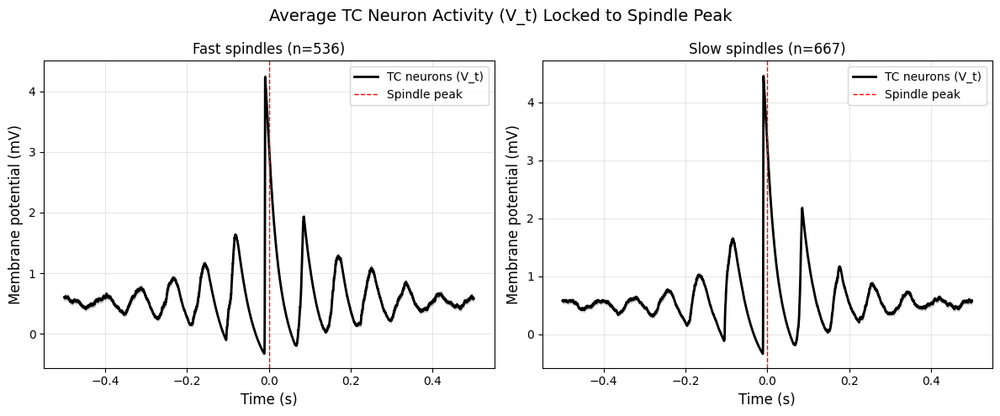

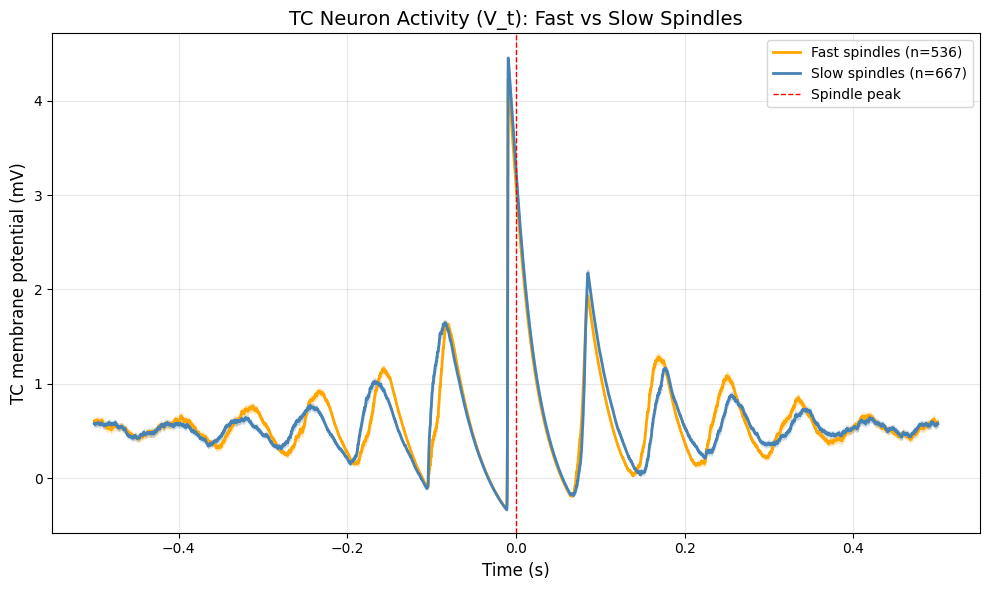


波形差异统计

快纺锤波:
  峰峰值幅度: 4.5612 mV
  最大峰值时间: -0.009 s

慢纺锤波:
  峰峰值幅度: 4.7903 mV
  最大峰值时间: -0.009 s

差异:
  幅度比 (快/慢): 0.952
  时间差: -0.000 s


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
window_before = 0.5 #1.0   # 纺锤波峰值前 1 秒
window_after = 0.5 #1.0    # 纺锤波峰值后 1 秒
window_samples = int((window_before + window_after) * sf)  # 总采样点数 = 20000

raw_data_dir = r"D:\mynew\demo_all\data\raw_data_scale0x0013_c2tsc0x8"
csv_path = r"D:\mynew\demo_all\data\analysis_data\spindles_all_with_mask.csv"

# ========== 2. 读取纺锤波检测结果 ==========
df = pd.read_csv(csv_path)
df_filtered = df[(df['c2tsc'] == 0.8) & (df['scale2'] == 0.0013)]

if 'masked' in df_filtered.columns:
    df_filtered = df_filtered[~df_filtered['masked']]

print(f"总纺锤波数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

# ========== 3. 按 seed 分组 ==========
npy_files = glob.glob(os.path.join(raw_data_dir, "*.npy"))
seed_to_file = {}
for f in npy_files:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    seed = int(parts[-1])
    seed_to_file[seed] = f

print(f"\n找到 {len(seed_to_file)} 个 npy 文件")

# ========== 4. 提取 TC 神经元（V_t）事件锁定信号 ==========
def extract_event_locked_Vt(seed, peak_time, V_t, sf, window_samples):
    """提取以纺锤波峰值为中心的 V_t 信号片段，统一长度"""
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    
    # 如果信号长度不够，用 NaN 填充或跳过
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    
    Vt_segment = V_t[start_idx:end_idx]
    
    # 确保长度一致
    if len(Vt_segment) != window_samples:
        return None
    
    return Vt_segment

fast_Vt_all = []
slow_Vt_all = []

for idx, row in df_filtered.iterrows():
    seed = int(row['seed'])
    peak_time = row['peak_time']
    spindle_type = row['type']
    
    if seed not in seed_to_file:
        continue
    
    data = np.load(seed_to_file[seed], allow_pickle=True).item()
    V_t = data["V_t"]
    
    Vt_seg = extract_event_locked_Vt(seed, peak_time, V_t, sf, window_samples)
    
    if Vt_seg is None:
        continue
    
    if spindle_type == 'fast':
        fast_Vt_all.append(Vt_seg)
    else:
        slow_Vt_all.append(Vt_seg)

# 转换为数组并计算平均值和 SEM
time_axis = np.linspace(-window_before, window_after, window_samples)

def compute_avg_and_sem(data_list):
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

if fast_Vt_all:
    fast_Vt_mean, fast_Vt_sem = compute_avg_and_sem(fast_Vt_all)
    fast_n = len(fast_Vt_all)
else:
    fast_n = 0

if slow_Vt_all:
    slow_Vt_mean, slow_Vt_sem = compute_avg_and_sem(slow_Vt_all)
    slow_n = len(slow_Vt_all)
else:
    slow_n = 0

print(f"\n快纺锤波对齐片段: n={fast_n}")
print(f"慢纺锤波对齐片段: n={slow_n}")

# ========== 5. 画图：两幅 V_t 图（快纺锤波 vs 慢纺锤波）==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：快纺锤波
ax = axes[0]
ax.plot(time_axis, fast_Vt_mean, 'k-', linewidth=2, label='TC neurons (V_t)')
ax.fill_between(time_axis, fast_Vt_mean - fast_Vt_sem, fast_Vt_mean + fast_Vt_sem, 
                color='black', alpha=0.2)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Spindle peak')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Membrane potential (mV)', fontsize=12)
ax.set_title(f'Fast spindles (n={fast_n})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波
ax = axes[1]
if slow_n > 0:
    ax.plot(time_axis, slow_Vt_mean, 'k-', linewidth=2, label='TC neurons (V_t)')
    ax.fill_between(time_axis, slow_Vt_mean - slow_Vt_sem, slow_Vt_mean + slow_Vt_sem, 
                    color='black', alpha=0.2)
else:
    ax.text(0, 0, 'No slow spindle data', ha='center', va='center')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Spindle peak')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Membrane potential (mV)', fontsize=12)
ax.set_title(f'Slow spindles (n={slow_n})', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Average TC Neuron Activity (V_t) Locked to Spindle Peak', fontsize=14)
plt.tight_layout()
#plt.savefig('analysis_data/Vt_locked_to_spindle_peak_fast_slow.png', dpi=150)
plt.show()

# ========== 6. 叠加对比图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

if fast_n > 0:
    ax.plot(time_axis, fast_Vt_mean, 'orange', linewidth=2, label=f'Fast spindles (n={fast_n})')
    ax.fill_between(time_axis, fast_Vt_mean - fast_Vt_sem, fast_Vt_mean + fast_Vt_sem, 
                    color='orange', alpha=0.2)

if slow_n > 0:
    ax.plot(time_axis, slow_Vt_mean, 'steelblue', linewidth=2, label=f'Slow spindles (n={slow_n})')
    ax.fill_between(time_axis, slow_Vt_mean - slow_Vt_sem, slow_Vt_mean + slow_Vt_sem, 
                    color='steelblue', alpha=0.2)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Spindle peak')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('TC membrane potential (mV)', fontsize=12)
ax.set_title('TC Neuron Activity (V_t): Fast vs Slow Spindles', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('analysis_data/Vt_fast_vs_slow_spindles_overlay.png', dpi=150)
plt.show()

# ========== 7. 打印差异统计 ==========
print("\n" + "="*60)
print("波形差异统计")
print("="*60)

if fast_n > 0 and slow_n > 0:
    # 计算峰峰值幅度
    fast_peak_amplitude = np.max(fast_Vt_mean) - np.min(fast_Vt_mean)
    slow_peak_amplitude = np.max(slow_Vt_mean) - np.min(slow_Vt_mean)
    
    # 计算峰值时刻（0 秒前后）
    fast_peak_idx = np.argmax(fast_Vt_mean)
    slow_peak_idx = np.argmax(slow_Vt_mean)
    fast_peak_time = time_axis[fast_peak_idx]
    slow_peak_time = time_axis[slow_peak_idx]
    
    print(f"\n快纺锤波:")
    print(f"  峰峰值幅度: {fast_peak_amplitude:.4f} mV")
    print(f"  最大峰值时间: {fast_peak_time:.3f} s")
    
    print(f"\n慢纺锤波:")
    print(f"  峰峰值幅度: {slow_peak_amplitude:.4f} mV")
    print(f"  最大峰值时间: {slow_peak_time:.3f} s")
    
    print(f"\n差异:")
    print(f"  幅度比 (快/慢): {fast_peak_amplitude/slow_peak_amplitude:.3f}")
    print(f"  时间差: {fast_peak_time - slow_peak_time:.3f} s")

#### a=8.4 Jrt -0.5->-1.5 raw_data_a8.4_Jrt_scan

In [6]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10                    # 每个参数值运行 10 次
a_fixed = 8.4                  # 固定 a 值
c2tsc = 0.0                    # 固定 c2tsc
scale2 = 0.0                   # 固定 scale2

# Jrt 范围：-0.5 到 -1.5，取 11 个值
Jrt_list = np.linspace(-0.2, -0.5, 4)

print("="*60)
print("参数扫描设置")
print("="*60)
print(f"a = {a_fixed}")
print(f"Jrt 值列表: {Jrt_list}")
print(f"c2tsc: {c2tsc}")
print(f"scale2: {scale2}")
print(f"每个参数 seed 数: {n_runs}")
print(f"总运行次数: {len(Jrt_list) * n_runs}")

# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件 ==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 运行任务 ==========
total_tasks = len(Jrt_list) * n_runs
completed = 0
skipped = 0

for Jrt_val in Jrt_list:
    for seed in range(1, n_runs + 1):
        # 生成文件名
        filename = f"a_{a_fixed:.4f}_Jrt_{Jrt_val:.4f}_c2tsc_{c2tsc:.4f}_scale2_{scale2:.6f}_seed_{seed}.npy"
        save_path = os.path.join(DATA_DIR, filename)
        
        # 如果文件已存在，跳过
        if filename in existing_files:
            print(f"跳过: {filename}")
            skipped += 1
            continue
        
        # 加载默认参数并修改
        params = dp.loadDefaultParams(seed)
        
        # 固定 a 值
        params["a"] = a_fixed
        params["VT_t"] = 26 - a_fixed
        params["VT_r"] = 23 - a_fixed
        params["VB_t"] = 15 - a_fixed
        params["VB_r"] = 15 - a_fixed
        
        # 修改 Jrt
        params["Jrt"] = Jrt_val
        
        # 固定 c2tsc 和 scale2
        params["c2tsc"] = c2tsc
        params["scale2"] = scale2
        
        # 运行模型
        try:
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        except Exception as e:
            print(f"失败: {filename}, 错误: {e}")
            continue
        
        # 保存 raw 信号
        np.save(save_path, {
            "t": t, "V_e": V_e, "V_i": V_i, 
            "Q_e": Q_e, "Q_i": Q_i, 
            "V_t": V_t, "V_r": V_r, 
            "Q_t": Q_t, "Q_r": Q_r,
            "a": a_fixed,
            "Jrt": Jrt_val,
            "c2tsc": c2tsc,
            "scale2": scale2,
            "seed": seed
        })
        
        completed += 1
        if completed % 10 == 0:
            print(f"进度: {completed}/{total_tasks - skipped}")

print("\n" + "="*60)
print("完成统计")
print("="*60)
print(f"总任务数: {total_tasks}")
print(f"新运行: {completed}")
print(f"跳过已存在: {skipped}")
print(f"数据保存在: {DATA_DIR}")

# ========== 显示生成的文件统计 ==========
print("\n生成的文件统计:")
for Jrt_val in Jrt_list:
    count = 0
    for f in os.listdir(DATA_DIR):
        if f.endswith(".npy") and f"Jrt_{Jrt_val:.4f}" in f:
            count += 1
    print(f"  Jrt={Jrt_val:.4f}: {count} 个文件")

参数扫描设置
a = 8.4
Jrt 值列表: [-0.2 -0.3 -0.4 -0.5]
c2tsc: 0.0
scale2: 0.0
每个参数 seed 数: 10
总运行次数: 40

已存在 170 个文件
进度: 10/40
进度: 20/40
进度: 30/40
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_1.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_2.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_3.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_4.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_5.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_6.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_7.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_8.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_9.npy
跳过: a_8.4000_Jrt_-0.5000_c2tsc_0.0000_scale2_0.000000_seed_10.npy

完成统计
总任务数: 40
新运行: 30
跳过已存在: 10
数据保存在: data/raw_data_a8.4_Jrt_scan

生成的文件统计:
  Jrt=-0.2000: 10 个文件
  Jrt=-0.3000: 10 个文件
  Jrt=-0.4000: 10 个文件
  Jrt=-0.5000: 10 个文件


#### Jrt_scan spindles.csv

In [7]:
import numpy as np
import pandas as pd
import yasa
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"
OUTPUT_CSV = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"

# ========== 2. 读取所有文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# ========== 3. 检测纺锤波 ==========
all_spindles = []

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    a_val = float(parts[1])
    Jrt_val = float(parts[3])
    c2tsc = float(parts[5])
    scale2 = float(parts[7])
    seed = int(parts[9])
    
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    
    # 检测快纺锤波 (12-16 Hz)
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    if sp_fast is not None:
        df_fast = sp_fast.summary()
        for _, row in df_fast.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jrt": Jrt_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "fast",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })
    
    # 检测慢纺锤波 (8-12 Hz)
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    if sp_slow is not None:
        df_slow = sp_slow.summary()
        for _, row in df_slow.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jrt": Jrt_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "slow",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })

# ========== 4. 保存 CSV ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df_spindles = pd.DataFrame(all_spindles)
df_spindles.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(df_spindles)} 个纺锤波")
print(f"快纺锤波: {len(df_spindles[df_spindles['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_spindles[df_spindles['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# ========== 5. 打印各 Jrt 值统计 ==========
print("\n各 Jrt 值统计:")
for Jrt_val in sorted(df_spindles['Jrt'].unique()):
    subset = df_spindles[df_spindles['Jrt'] == Jrt_val]
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    print(f"  Jrt={Jrt_val:.4f}: fast={fast_count}, slow={slow_count}, total={len(subset)}")

找到 200 个文件


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
29-Jul-26 17:08:04 | WARNING | No spindle were found in channel CHAN000.
29-Jul-26 17:08:04 | WARNING | No spindles were found in data. Returning None.
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:   


总共检测到 2175 个纺锤波
快纺锤波: 1039
慢纺锤波: 1136
CSV 已保存: data/analysis_data/spindles_a8.4_Jrt_scan.csv

各 Jrt 值统计:
  Jrt=-1.5000: fast=11, slow=0, total=11
  Jrt=-1.4000: fast=5, slow=0, total=5
  Jrt=-1.3000: fast=59, slow=1, total=60
  Jrt=-1.2000: fast=77, slow=1, total=78
  Jrt=-1.1000: fast=96, slow=5, total=101
  Jrt=-1.0000: fast=85, slow=8, total=93
  Jrt=-0.9000: fast=86, slow=18, total=104
  Jrt=-0.8000: fast=67, slow=63, total=130
  Jrt=-0.7000: fast=78, slow=80, total=158
  Jrt=-0.6750: fast=66, slow=93, total=159
  Jrt=-0.6500: fast=55, slow=86, total=141
  Jrt=-0.6250: fast=67, slow=89, total=156
  Jrt=-0.6000: fast=66, slow=74, total=140
  Jrt=-0.5750: fast=65, slow=92, total=157
  Jrt=-0.5500: fast=55, slow=102, total=157
  Jrt=-0.5250: fast=53, slow=96, total=149
  Jrt=-0.5000: fast=35, slow=95, total=130
  Jrt=-0.4000: fast=11, slow=85, total=96
  Jrt=-0.3000: fast=2, slow=85, total=87
  Jrt=-0.2000: fast=0, slow=63, total=63


### 不同Jrt所引发的快慢纺锤个数等分析

读取 2175 个纺锤波

Jrt 值: [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.675, -0.65, -0.625, -0.6, -0.575, -0.55, -0.525, -0.5, -0.4, -0.3, -0.2]

平均总时长统计（每个 seed 先统计总时长，再对 seed 平均）

--- Jrt = -1.500 ---
  fast: mean_total_duration=0.878±0.258s (n_seeds=6)

--- Jrt = -1.400 ---
  fast: mean_total_duration=0.575±0.290s (n_seeds=4)

--- Jrt = -1.300 ---
  fast: mean_total_duration=4.144±0.574s (n_seeds=10)
  slow: mean_total_duration=0.712±nans (n_seeds=1)

--- Jrt = -1.200 ---
  fast: mean_total_duration=4.632±0.430s (n_seeds=10)
  slow: mean_total_duration=0.595±nans (n_seeds=1)

--- Jrt = -1.100 ---
  fast: mean_total_duration=6.217±1.727s (n_seeds=10)
  slow: mean_total_duration=0.537±0.298s (n_seeds=4)

--- Jrt = -1.000 ---
  fast: mean_total_duration=7.327±0.770s (n_seeds=10)
  slow: mean_total_duration=0.502±0.254s (n_seeds=8)

--- Jrt = -0.900 ---
  fast: mean_total_duration=5.550±1.234s (n_seeds=10)
  slow: mean_total_duration=0.775±0.601s (n_seeds=10)

--- Jrt = -0.800 --

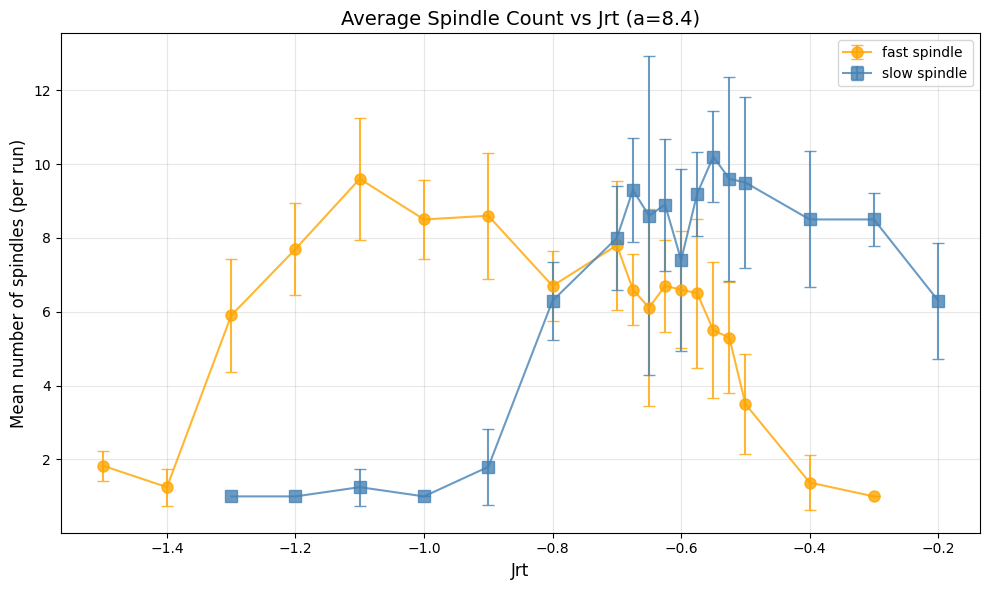

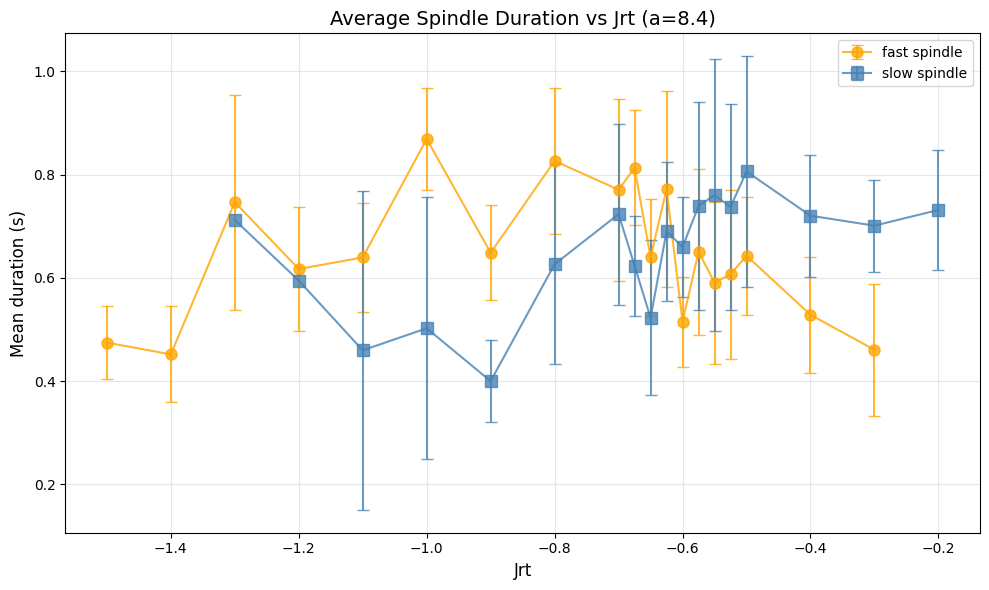

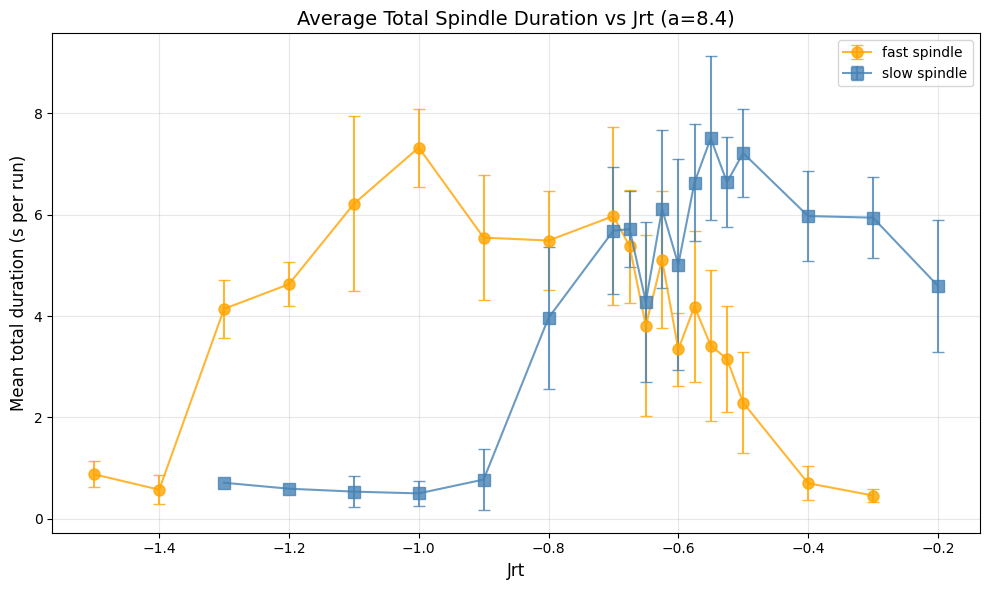

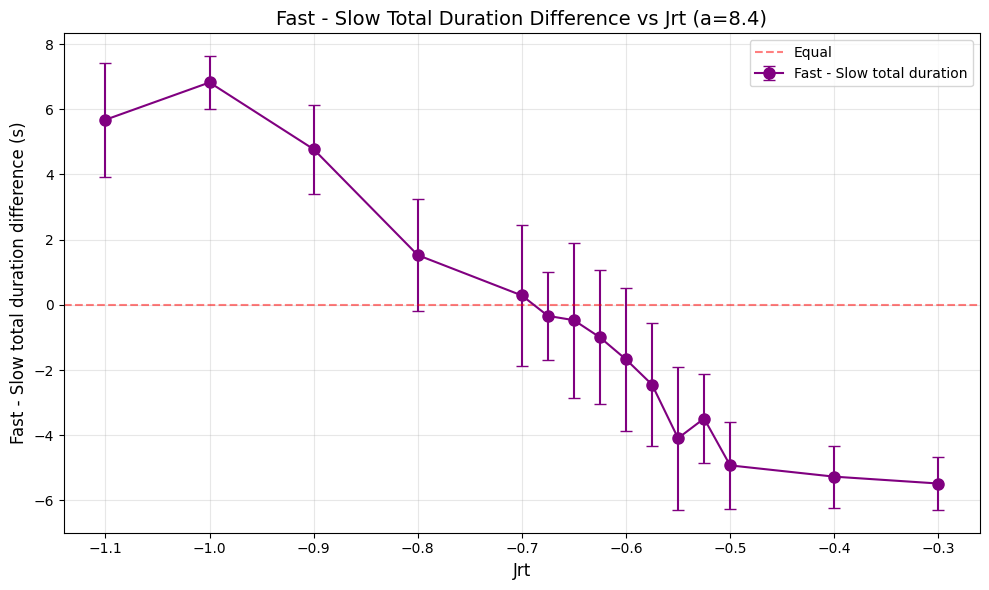


统计检验：每个 Jrt 下快慢纺锤波总时长比较
Jrt=-1.300: fast_n=10, slow_n=1, fast_mean=4.14s, slow_mean=0.71s, p=0.1818 (不显著)
Jrt=-1.200: fast_n=10, slow_n=1, fast_mean=4.63s, slow_mean=0.59s, p=0.1818 (不显著)
Jrt=-1.100: fast_n=10, slow_n=4, fast_mean=6.22s, slow_mean=0.54s, p=0.0020 (显著)
Jrt=-1.000: fast_n=10, slow_n=8, fast_mean=7.33s, slow_mean=0.50s, p=0.0000 (显著)
Jrt=-0.900: fast_n=10, slow_n=10, fast_mean=5.55s, slow_mean=0.78s, p=0.0002 (显著)
Jrt=-0.800: fast_n=10, slow_n=10, fast_mean=5.49s, slow_mean=3.97s, p=0.0311 (显著)
Jrt=-0.700: fast_n=10, slow_n=10, fast_mean=5.97s, slow_mean=5.69s, p=0.6232 (不显著)
Jrt=-0.675: fast_n=10, slow_n=10, fast_mean=5.38s, slow_mean=5.72s, p=0.5205 (不显著)
Jrt=-0.650: fast_n=9, slow_n=10, fast_mean=3.81s, slow_mean=4.28s, p=0.3074 (不显著)
Jrt=-0.625: fast_n=10, slow_n=10, fast_mean=5.12s, slow_mean=6.12s, p=0.1859 (不显著)
Jrt=-0.600: fast_n=10, slow_n=10, fast_mean=3.34s, slow_mean=5.02s, p=0.1041 (不显著)
Jrt=-0.575: fast_n=10, slow_n=10, fast_mean=4.19s, slow_mean=6.64s, p=0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ========== 1. 读取数据 ==========
CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"
df = pd.read_csv(CSV_PATH)

print(f"读取 {len(df)} 个纺锤波")

# ========== 2. 查看 Jrt 的取值范围 ==========
Jrt_values = sorted(df['Jrt'].unique())
print(f"\nJrt 值: {Jrt_values}")

# ========== 3. 按 Jrt, seed, type 分组统计每个 seed 的总时长 ==========
seed_total_duration = df.groupby(['Jrt', 'seed', 'type'])['duration'].sum().reset_index(name='total_duration')

# 再按 Jrt 和 type 分组，计算所有 seed 的平均总时长和标准差
total_duration_stats = seed_total_duration.groupby(['Jrt', 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    n_seeds=('total_duration', 'count')
).reset_index()

print("\n" + "="*60)
print("平均总时长统计（每个 seed 先统计总时长，再对 seed 平均）")
print("="*60)

for Jrt_val in Jrt_values:
    print(f"\n--- Jrt = {Jrt_val:.3f} ---")
    for spindle_type in ['fast', 'slow']:
        subset = total_duration_stats[(total_duration_stats['Jrt'] == Jrt_val) & 
                                      (total_duration_stats['type'] == spindle_type)]
        if len(subset) > 0:
            row = subset.iloc[0]
            print(f"  {spindle_type}: mean_total_duration={row['mean_total_duration']:.3f}±{row['std_total_duration']:.3f}s (n_seeds={row['n_seeds']:.0f})")

# ========== 4. 图1：平均纺锤波个数（折线图，带误差棒）==========
# 先按 Jrt, seed, type 分组统计每个 seed 的个数
seed_counts = df.groupby(['Jrt', 'seed', 'type']).size().reset_index(name='count')
count_stats = seed_counts.groupby(['Jrt', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    n_seeds=('count', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = count_stats[count_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_count'], 
                    yerr=subset_sorted['std_count'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean number of spindles (per run)', fontsize=12)
ax.set_title('Average Spindle Count vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 5. 图2：平均持续时长（折线图，带误差棒）==========
# 先按 Jrt, seed, type 分组统计每个 seed 的平均时长
seed_durations = df.groupby(['Jrt', 'seed', 'type'])['duration'].mean().reset_index(name='mean_duration')
duration_stats = seed_durations.groupby(['Jrt', 'type']).agg(
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
    n_seeds=('mean_duration', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = duration_stats[duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_duration'], 
                    yerr=subset_sorted['std_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean duration (s)', fontsize=12)
ax.set_title('Average Spindle Duration vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 6. 图3：总时长（折线图，带误差棒）==========
fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = total_duration_stats[total_duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_total_duration'], 
                    yerr=subset_sorted['std_total_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean total duration (s per run)', fontsize=12)
ax.set_title('Average Total Spindle Duration vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 图4：快慢差值（总时长差值）==========
# 合并快慢数据计算差值
fast_total = total_duration_stats[total_duration_stats['type'] == 'fast'][['Jrt', 'mean_total_duration', 'std_total_duration']].rename(
    columns={'mean_total_duration': 'fast_mean', 'std_total_duration': 'fast_std'})
slow_total = total_duration_stats[total_duration_stats['type'] == 'slow'][['Jrt', 'mean_total_duration', 'std_total_duration']].rename(
    columns={'mean_total_duration': 'slow_mean', 'std_total_duration': 'slow_std'})

diff_stats = pd.merge(fast_total, slow_total, on='Jrt', how='outer')
diff_stats = diff_stats.dropna()
diff_stats['diff'] = diff_stats['fast_mean'] - diff_stats['slow_mean']
diff_stats['diff_std'] = np.sqrt(diff_stats['fast_std']**2 + diff_stats['slow_std']**2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(diff_stats['Jrt'], diff_stats['diff'], 
            yerr=diff_stats['diff_std'],
            fmt='o-', color='purple', capsize=4,
            label='Fast - Slow total duration', markersize=8, linewidth=1.5)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Equal')
ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Fast - Slow total duration difference (s)', fontsize=12)
ax.set_title('Fast - Slow Total Duration Difference vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 统计检验 ==========
print("\n" + "="*60)
print("统计检验：每个 Jrt 下快慢纺锤波总时长比较")
print("="*60)

for Jrt_val in Jrt_values:
    fast_total_seed = seed_total_duration[(seed_total_duration['Jrt'] == Jrt_val) & 
                                          (seed_total_duration['type'] == 'fast')]['total_duration'].values
    slow_total_seed = seed_total_duration[(seed_total_duration['Jrt'] == Jrt_val) & 
                                          (seed_total_duration['type'] == 'slow')]['total_duration'].values
    
    if len(fast_total_seed) > 0 and len(slow_total_seed) > 0:
        u, p = mannwhitneyu(fast_total_seed, slow_total_seed)
        print(f"Jrt={Jrt_val:.3f}: fast_n={len(fast_total_seed)}, slow_n={len(slow_total_seed)}, "
              f"fast_mean={np.mean(fast_total_seed):.2f}s, slow_mean={np.mean(slow_total_seed):.2f}s, "
              f"p={p:.4f} ({'显著' if p < 0.05 else '不显著'})")

# ========== 9. 找最佳参数 ==========
print("\n" + "="*60)
print("最佳参数总结（基于平均总时长）")
print("="*60)

# 快纺锤波总时长最多的 Jrt
fast_max_idx = total_duration_stats[total_duration_stats['type'] == 'fast']['mean_total_duration'].idxmax()
best_Jrt_fast = total_duration_stats.loc[fast_max_idx, 'Jrt']
best_fast = total_duration_stats.loc[fast_max_idx, 'mean_total_duration']

# 慢纺锤波总时长最多的 Jrt
slow_max_idx = total_duration_stats[total_duration_stats['type'] == 'slow']['mean_total_duration'].idxmax()
best_Jrt_slow = total_duration_stats.loc[slow_max_idx, 'Jrt']
best_slow = total_duration_stats.loc[slow_max_idx, 'mean_total_duration']

print(f"快纺锤波总时长最多: Jrt={best_Jrt_fast:.3f}, total={best_fast:.2f}s")
print(f"慢纺锤波总时长最多: Jrt={best_Jrt_slow:.3f}, total={best_slow:.2f}s")

#### 追加：不同Jrt下的频谱

Jrt 值: [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.675, -0.65, -0.625, -0.6, -0.575, -0.55, -0.525, -0.5, -0.4, -0.3, -0.2]
找到 200 个文件


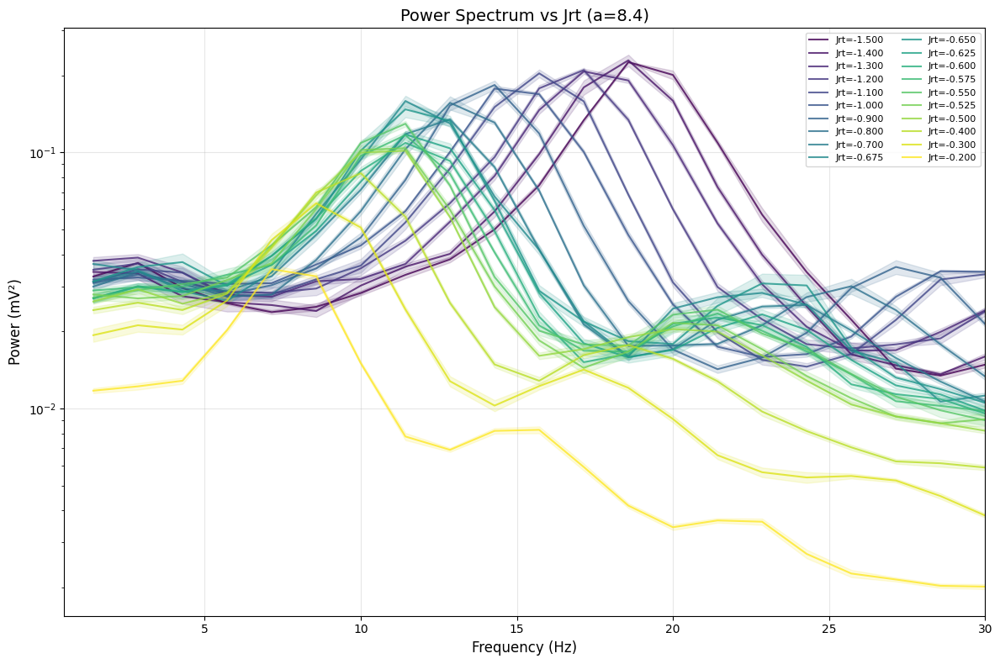

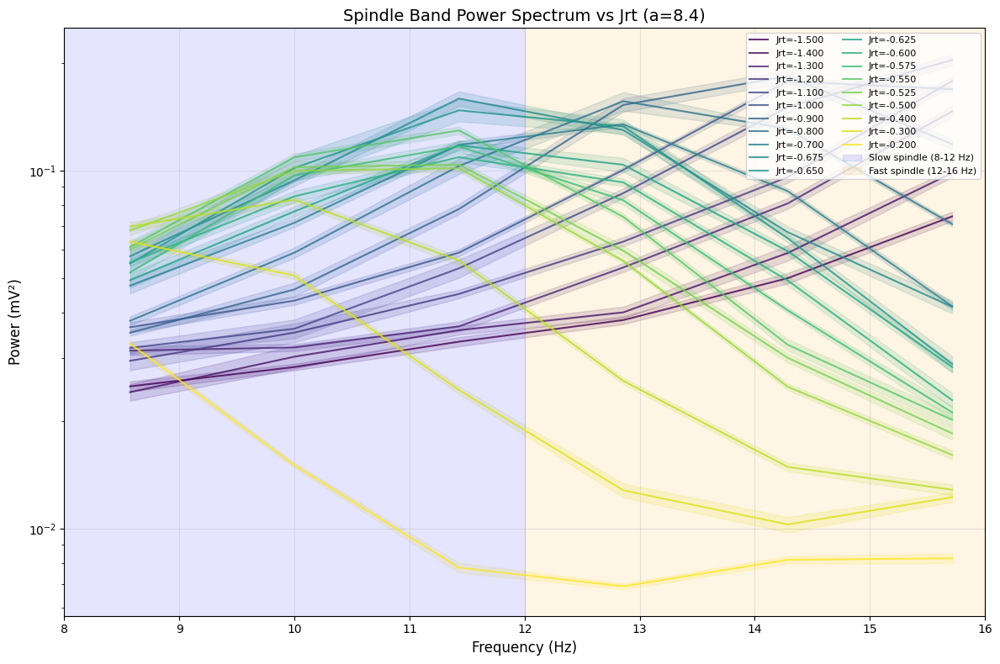

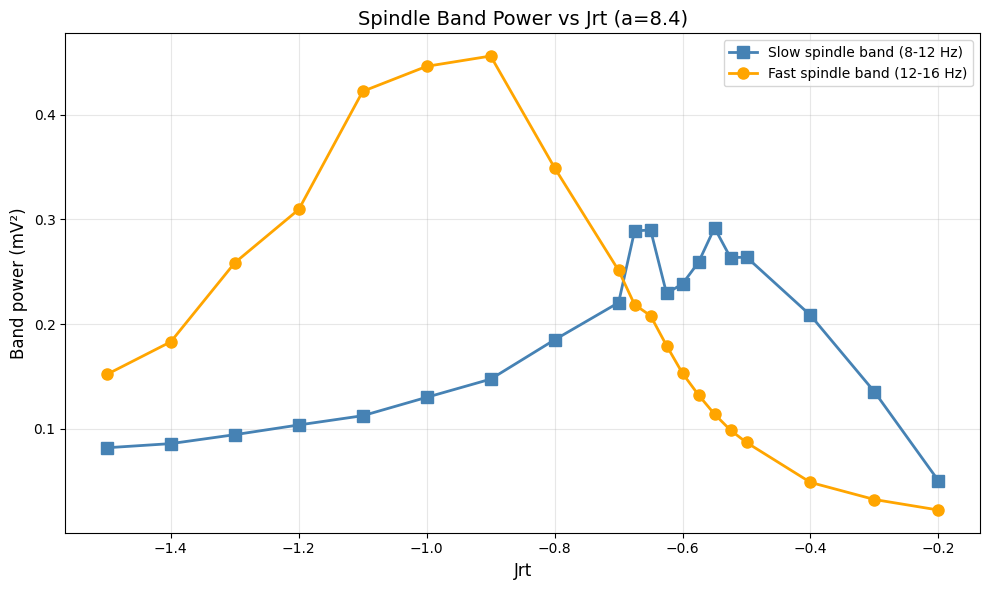

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
import matplotlib.ticker as ticker

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"  # 存放 npy 文件的目录
CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"

# PSD 参数
nperseg = int(sf * 0.7)  # 0.7 秒窗口
freq_range = (0.5, 30)   # 显示频率范围

# ========== 2. 读取 CSV 获取所有 Jrt 值 ==========
df = pd.read_csv(CSV_PATH)
Jrt_values = sorted(df['Jrt'].unique())
print(f"Jrt 值: {Jrt_values}")

# ========== 3. 建立文件映射：每个 (Jrt, seed) 对应的文件路径 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for f in file_list:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    # 根据你的文件名格式: a_8.4000_Jrt_-0.5000_..._seed_1
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = f

print(f"找到 {len(file_map)} 个文件")

# ========== 4. 对每个 Jrt 计算平均 PSD ==========
# 统一频率轴
freqs = None
psd_by_Jrt = {}  # {Jrt: {'fast': [psd_list], 'slow': [psd_list]}}
spindle_info_by_Jrt = {}  # 存储每个 Jrt 下每个 seed 的纺锤波信息

for Jrt_val in Jrt_values:
    # 找该 Jrt 下所有的 seed
    seeds = df[df['Jrt'] == Jrt_val]['seed'].unique()
    psd_list_fast = []
    psd_list_slow = []
    
    for seed in seeds:
        key = (Jrt_val, seed)
        if key not in file_map:
            continue
        
        # 加载数据
        data = np.load(file_map[key], allow_pickle=True).item()
        V_t = data["V_t"]
        
        # 计算 PSD
        f, Pxx = signal.welch(V_t, sf, nperseg=nperseg, scaling='spectrum')
        
        if freqs is None:
            freqs = f
        
        # 找该 seed 下快慢纺锤波的持续时间（用于后续按需分析）
        # 这里我们直接保存 PSD
        psd_list_fast.append(Pxx)
        psd_list_slow.append(Pxx)  # 暂存，用于分组
    
    # 对同一 Jrt 下的所有 PSD 求平均和标准差
    if len(psd_list_fast) > 0:
        psd_array_fast = np.array(psd_list_fast)
        psd_by_Jrt[Jrt_val] = {
            'fast': {
                'mean': np.mean(psd_array_fast, axis=0),
                'std': np.std(psd_array_fast, axis=0),
                'n': len(psd_array_fast)
            }
        }
        
        # 慢纺锤波也可以用同样的数据（因为 PSD 是所有频段的，不区分纺锤波类型）
        # 但如果你想要分别分析快慢纺锤波期间的 PSD，需要根据纺锤波事件截取信号
        # 这里我们先用全信号 PSD
        psd_by_Jrt[Jrt_val]['slow'] = {
            'mean': np.mean(psd_array_fast, axis=0),
            'std': np.std(psd_array_fast, axis=0),
            'n': len(psd_array_fast)
        }

# ========== 5. 画图：所有 Jrt 的 PSD 叠加 ==========
fig, ax = plt.subplots(figsize=(12, 8))

# 颜色映射
colors = plt.cm.viridis(np.linspace(0, 1, len(Jrt_values)))

for i, Jrt_val in enumerate(Jrt_values):
    if Jrt_val not in psd_by_Jrt:
        continue
    data = psd_by_Jrt[Jrt_val]['fast']
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.5, 
                label=f'Jrt={Jrt_val:.3f}', alpha=0.8)
    # 添加误差带（±SEM）
    sem = data['std'] / np.sqrt(data['n'])
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Power Spectrum vs Jrt (a=8.4)', fontsize=14)
ax.set_xlim(freq_range[0], freq_range[1])
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# 设置 Y 轴刻度
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=5))
plt.tight_layout()
plt.show()

# ========== 6. 画图：纺锤波频段放大（8–16 Hz）==========
fig, ax = plt.subplots(figsize=(12, 8))

for i, Jrt_val in enumerate(Jrt_values):
    if Jrt_val not in psd_by_Jrt:
        continue
    data = psd_by_Jrt[Jrt_val]['fast']
    mask = (freqs >= 8) & (freqs <= 16)
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.5, 
                label=f'Jrt={Jrt_val:.3f}', alpha=0.8)
    
    sem = data['std'] / np.sqrt(data['n'])
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

# 标记快慢纺锤波频段
ax.axvspan(8, 12, alpha=0.1, color='blue', label='Slow spindle (8-12 Hz)')
ax.axvspan(12, 16, alpha=0.1, color='orange', label='Fast spindle (12-16 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power Spectrum vs Jrt (a=8.4)', fontsize=14)
ax.set_xlim(8, 16)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 提取纺锤波频段功率并画图 ==========
# 计算每个 Jrt 下纺锤波频段的平均功率
band_power_stats = []

for Jrt_val in Jrt_values:
    if Jrt_val not in psd_by_Jrt:
        continue
    
    # 慢纺锤波频段 (8-12 Hz)
    slow_mask = (freqs >= 8) & (freqs <= 12)
    slow_power = np.trapz(psd_by_Jrt[Jrt_val]['fast']['mean'][slow_mask], freqs[slow_mask])
    
    # 快纺锤波频段 (12-16 Hz)
    fast_mask = (freqs >= 12) & (freqs <= 16)
    fast_power = np.trapz(psd_by_Jrt[Jrt_val]['fast']['mean'][fast_mask], freqs[fast_mask])
    
    band_power_stats.append({
        'Jrt': Jrt_val,
        'slow_band_power': slow_power,
        'fast_band_power': fast_power,
    })

band_power_df = pd.DataFrame(band_power_stats)

# 画图：纺锤波频段功率随 Jrt 变化
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(band_power_df['Jrt'], band_power_df['slow_band_power'], 
        's-', color='steelblue', linewidth=2, markersize=8, label='Slow spindle band (8-12 Hz)')
ax.plot(band_power_df['Jrt'], band_power_df['fast_band_power'], 
        'o-', color='orange', linewidth=2, markersize=8, label='Fast spindle band (12-16 Hz)')

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Band power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

所有 Jrt 值: [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.675, -0.65, -0.625, -0.6, -0.575, -0.55, -0.525, -0.5, -0.4, -0.3, -0.2]
共 20 个

选取的代表性 Jrt 值: [-1.5, -1.3, -1.1, -0.9, -0.8, -0.575, -0.4, -0.2]
共 8 个
找到 200 个文件


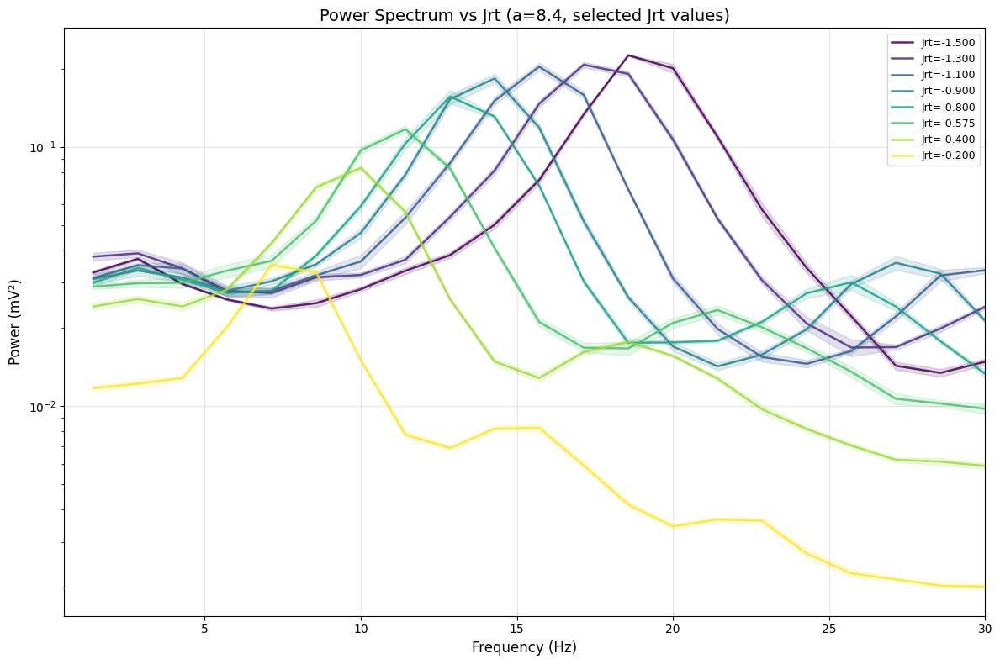

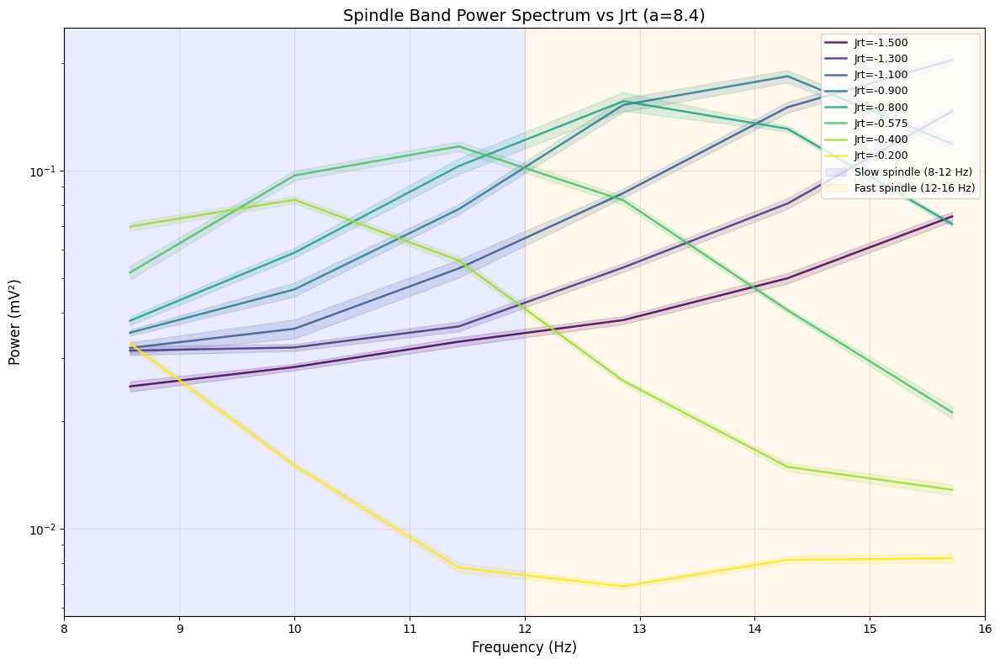

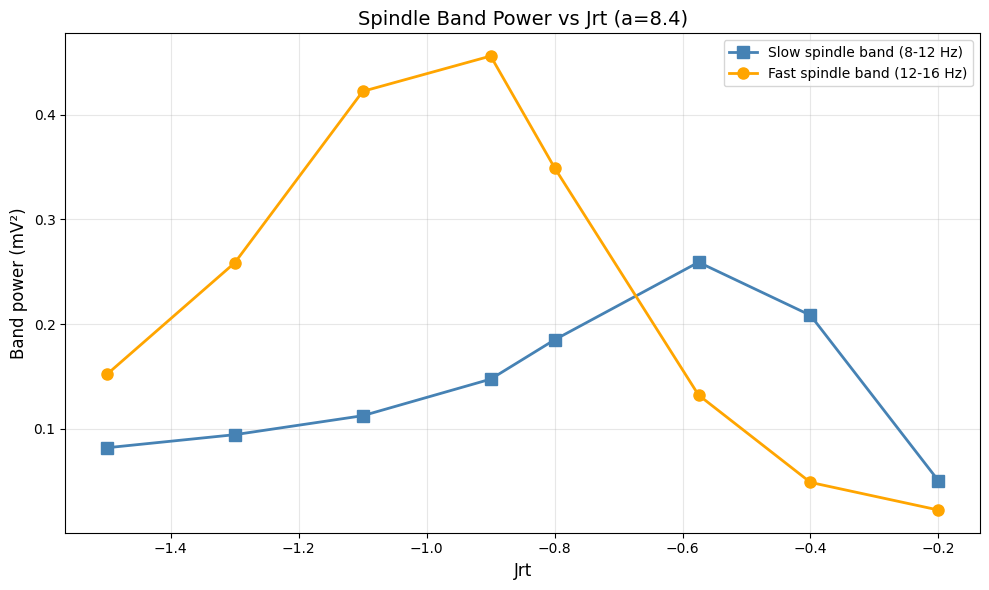


纺锤波频段总功率（选中的 Jrt 值）
Jrt=-1.500: slow=0.0819 mV², fast=0.1520 mV²
Jrt=-1.300: slow=0.0944 mV², fast=0.2586 mV²
Jrt=-1.100: slow=0.1125 mV², fast=0.4222 mV²
Jrt=-0.900: slow=0.1475 mV², fast=0.4559 mV²
Jrt=-0.800: slow=0.1850 mV², fast=0.3492 mV²
Jrt=-0.575: slow=0.2590 mV², fast=0.1323 mV²
Jrt=-0.400: slow=0.2084 mV², fast=0.0489 mV²
Jrt=-0.200: slow=0.0505 mV², fast=0.0225 mV²


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
import matplotlib.ticker as ticker

# ========== 1. 参数设置 ==========
sf = 10000
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"
CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"

nperseg = int(sf * 0.7)
freq_range = (0.5, 30)

# ========== 2. 读取 CSV 获取所有 Jrt 值 ==========
df = pd.read_csv(CSV_PATH)
all_Jrt_values = sorted(df['Jrt'].unique())
print(f"所有 Jrt 值: {all_Jrt_values}")
print(f"共 {len(all_Jrt_values)} 个")

# ========== 3. 选取代表性的 Jrt 值 ==========
# 方案1：均匀选取 8 个值（覆盖范围）
Jrt_values = np.linspace(all_Jrt_values[0], all_Jrt_values[-1], 8).tolist()
# 四舍五入到 3 位小数，匹配实际值
Jrt_values = [round(v, 3) for v in Jrt_values]
# 找实际数据中最近的值
Jrt_values = sorted(set([min(all_Jrt_values, key=lambda x: abs(x - v)) for v in Jrt_values]))

# 方案2：手动指定（根据你的关注点）
# Jrt_values = [-1.5, -1.2, -0.9, -0.6, -0.3, -0.5, -0.7, -1.0]

print(f"\n选取的代表性 Jrt 值: {Jrt_values}")
print(f"共 {len(Jrt_values)} 个")

# ========== 4. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for f in file_list:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = f

print(f"找到 {len(file_map)} 个文件")

# ========== 5. 对每个 Jrt 计算平均 PSD ==========
freqs = None
psd_by_Jrt = {}

for Jrt_val in Jrt_values:
    # 只处理选中的 Jrt 值
    seeds = df[df['Jrt'] == Jrt_val]['seed'].unique()
    psd_list = []
    
    for seed in seeds:
        key = (Jrt_val, seed)
        if key not in file_map:
            continue
        
        data = np.load(file_map[key], allow_pickle=True).item()
        V_t = data["V_t"]
        
        f, Pxx = signal.welch(V_t, sf, nperseg=nperseg, scaling='spectrum')
        
        if freqs is None:
            freqs = f
        
        psd_list.append(Pxx)
    
    if len(psd_list) > 0:
        psd_array = np.array(psd_list)
        psd_by_Jrt[Jrt_val] = {
            'mean': np.mean(psd_array, axis=0),
            'std': np.std(psd_array, axis=0),
            'n': len(psd_array)
        }

# ========== 6. 画图：全频段 ==========
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jrt_values)))

for i, Jrt_val in enumerate(Jrt_values):
    if Jrt_val not in psd_by_Jrt:
        continue
    data = psd_by_Jrt[Jrt_val]
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jrt={Jrt_val:.3f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Power Spectrum vs Jrt (a=8.4, selected Jrt values)', fontsize=14)
ax.set_xlim(freq_range[0], freq_range[1])
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=5))
plt.tight_layout()
plt.show()

# ========== 7. 画图：纺锤波频段放大（8–16 Hz）==========
fig, ax = plt.subplots(figsize=(12, 8))

for i, Jrt_val in enumerate(Jrt_values):
    if Jrt_val not in psd_by_Jrt:
        continue
    data = psd_by_Jrt[Jrt_val]
    mask = (freqs >= 8) & (freqs <= 16)
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jrt={Jrt_val:.3f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.axvspan(8, 12, alpha=0.08, color='blue', label='Slow spindle (8-12 Hz)')
ax.axvspan(12, 16, alpha=0.08, color='orange', label='Fast spindle (12-16 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power Spectrum vs Jrt (a=8.4)', fontsize=14)
ax.set_xlim(8, 16)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 频段总功率随 Jrt 变化 ==========
band_power_stats = []

for Jrt_val in Jrt_values:
    if Jrt_val not in psd_by_Jrt:
        continue
    
    slow_mask = (freqs >= 8) & (freqs <= 12)
    slow_power = np.trapz(psd_by_Jrt[Jrt_val]['mean'][slow_mask], freqs[slow_mask])
    
    fast_mask = (freqs >= 12) & (freqs <= 16)
    fast_power = np.trapz(psd_by_Jrt[Jrt_val]['mean'][fast_mask], freqs[fast_mask])
    
    band_power_stats.append({
        'Jrt': Jrt_val,
        'slow_band_power': slow_power,
        'fast_band_power': fast_power,
    })

band_power_df = pd.DataFrame(band_power_stats)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(band_power_df['Jrt'], band_power_df['slow_band_power'], 
        's-', color='steelblue', linewidth=2, markersize=8, label='Slow spindle band (8-12 Hz)')
ax.plot(band_power_df['Jrt'], band_power_df['fast_band_power'], 
        'o-', color='orange', linewidth=2, markersize=8, label='Fast spindle band (12-16 Hz)')

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Band power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power vs Jrt (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 9. 打印统计 ==========
print("\n" + "="*60)
print("纺锤波频段总功率（选中的 Jrt 值）")
print("="*60)

for _, row in band_power_df.iterrows():
    print(f"Jrt={row['Jrt']:.3f}: slow={row['slow_band_power']:.4f} mV², fast={row['fast_band_power']:.4f} mV²")

In [ ]:
alkhg;sldg

读取 2175 个纺锤波

各 Jrt 值纺锤波数量:
  Jrt=-1.500: fast=7, slow=0
  Jrt=-1.400: fast=5, slow=0
  Jrt=-1.300: fast=55, slow=1
  Jrt=-1.200: fast=73, slow=1
  Jrt=-1.100: fast=90, slow=5
  Jrt=-1.000: fast=81, slow=8
  Jrt=-0.900: fast=80, slow=16
  Jrt=-0.800: fast=65, slow=59
  Jrt=-0.700: fast=76, slow=75
  Jrt=-0.675: fast=62, slow=92
  Jrt=-0.650: fast=50, slow=80
  Jrt=-0.625: fast=64, slow=84
  Jrt=-0.600: fast=61, slow=70
  Jrt=-0.575: fast=65, slow=80
  Jrt=-0.550: fast=54, slow=90
  Jrt=-0.525: fast=49, slow=92
  Jrt=-0.500: fast=33, slow=87
  Jrt=-0.400: fast=10, slow=80
  Jrt=-0.300: fast=1, slow=81
  Jrt=-0.200: fast=0, slow=60


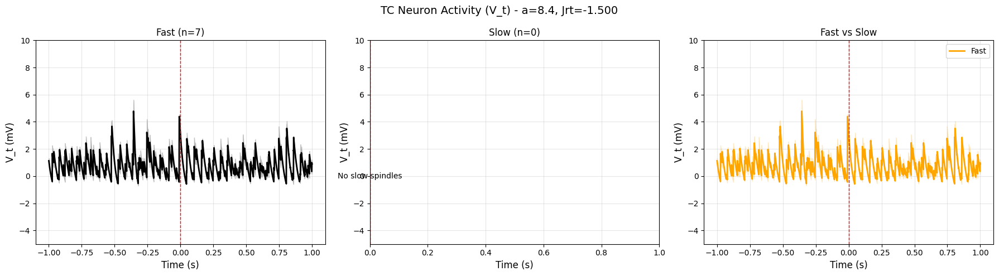

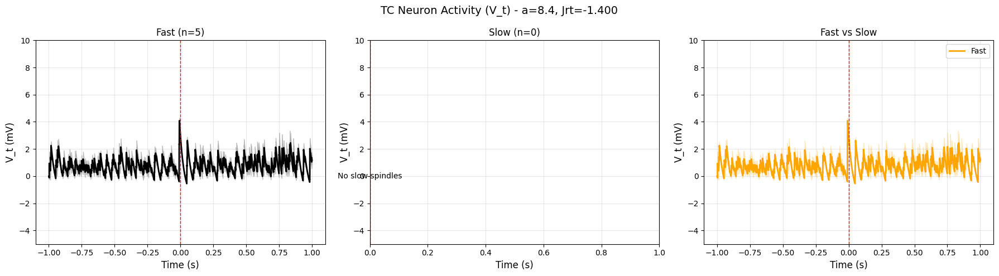

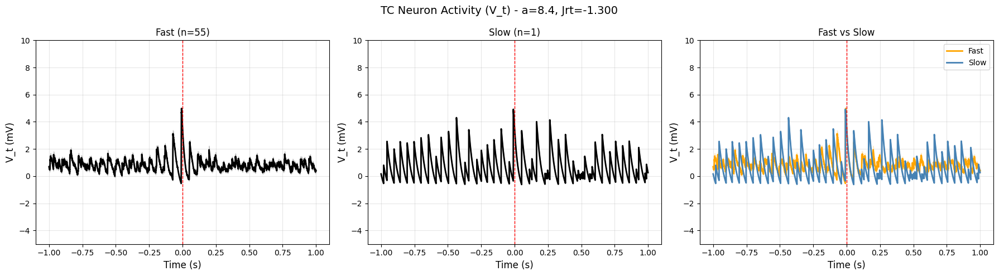

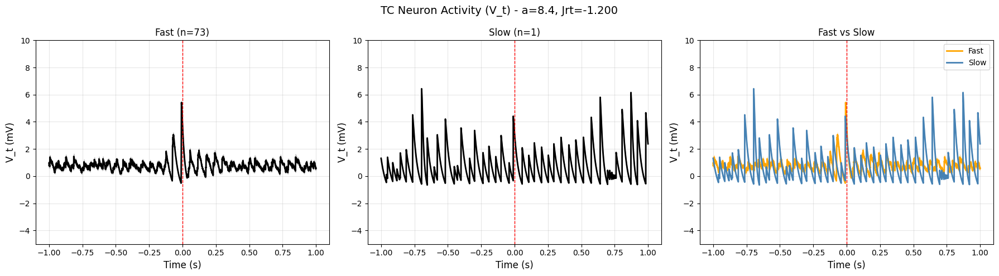

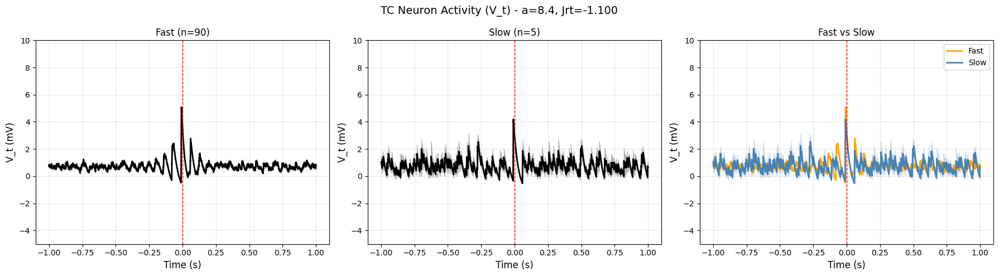

...

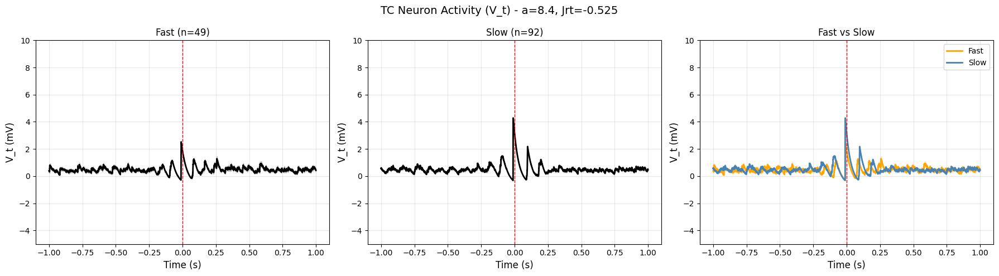

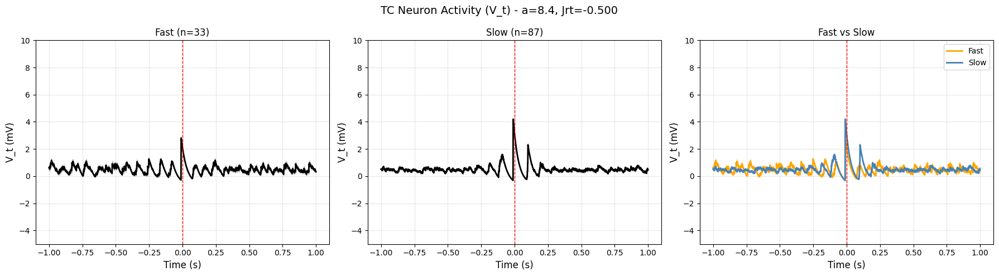

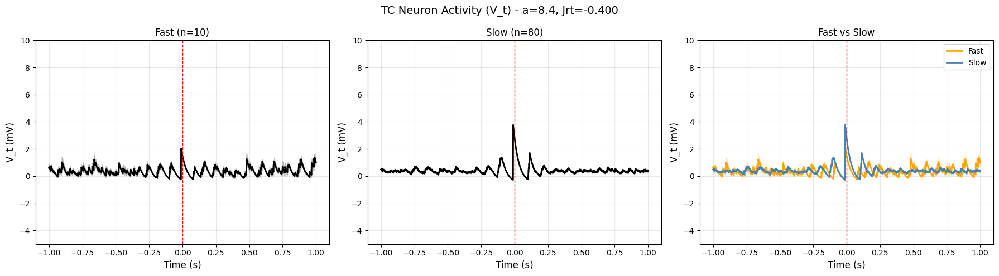

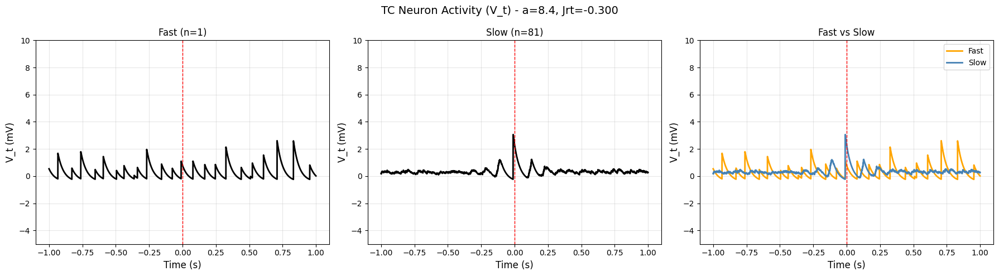

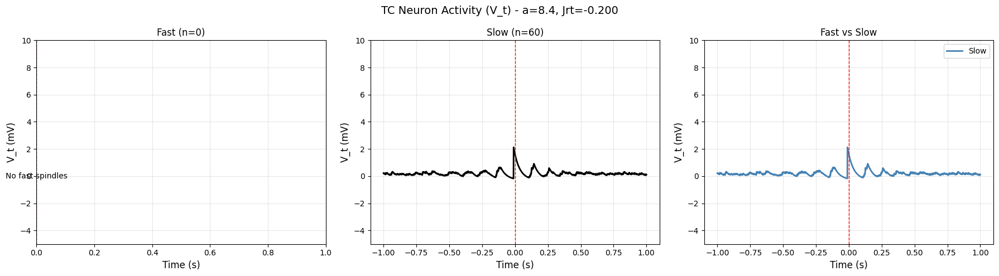

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000
window_before = 1.0
window_after = 1.0
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"

# ========== 2. 读取 CSV ==========
df_spindles = pd.read_csv(CSV_PATH)
print(f"读取 {len(df_spindles)} 个纺锤波")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

Jrt_values = sorted(df_spindles['Jrt'].unique())
Jrt_groups = {}
for Jrt_val in Jrt_values:
    Jrt_groups[Jrt_val] = {"fast": [], "slow": []}

for _, row in df_spindles.iterrows():
    Jrt_val = row["Jrt"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (Jrt_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        Jrt_groups[Jrt_val][spindle_type].append(seg)

# ========== 5. 计算均值和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

print("\n各 Jrt 值纺锤波数量:")
for Jrt_val in Jrt_values:
    fast_count = len(Jrt_groups[Jrt_val]["fast"])
    slow_count = len(Jrt_groups[Jrt_val]["slow"])
    print(f"  Jrt={Jrt_val:.3f}: fast={fast_count}, slow={slow_count}")

# ========== 6. 每个 Jrt 值画三张图在一行 ==========
for Jrt_val in Jrt_values:
    fast_segs = Jrt_groups[Jrt_val]["fast"]
    slow_segs = Jrt_groups[Jrt_val]["slow"]
    
    fast_mean, fast_sem = compute_mean_sem(fast_segs)
    slow_mean, slow_sem = compute_mean_sem(slow_segs)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 子图1：快纺锤波
    ax = axes[0]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'k-', linewidth=2)
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Fast (n={len(fast_segs)})', fontsize=12)
    else:
        ax.text(0, 0, 'No fast spindles', ha='center', va='center')
        ax.set_title('Fast (n=0)', fontsize=12)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    
    # 子图2：慢纺锤波
    ax = axes[1]
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'k-', linewidth=2)
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Slow (n={len(slow_segs)})', fontsize=12)
    else:
        ax.text(0, 0, 'No slow spindles', ha='center', va='center')
        ax.set_title('Slow (n=0)', fontsize=12)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    
    # 子图3：快慢叠加
    ax = axes[2]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'orange', linewidth=2, label='Fast')
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='orange', alpha=0.2)
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'steelblue', linewidth=2, label='Slow')
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='steelblue', alpha=0.2)
    if fast_mean is None and slow_mean is None:
        ax.text(0, 0, 'No spindles', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_title(f'Fast vs Slow', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'TC Neuron Activity (V_t) - a={8.4:.1f}, Jrt={Jrt_val:.3f}', fontsize=14)
    plt.tight_layout()
    plt.show()

读取 2175 个纺锤波

各 Jrt 值纺锤波数量:
  Jrt=-1.500: fast=7, slow=0
  Jrt=-1.400: fast=5, slow=0
  Jrt=-1.300: fast=55, slow=1
  Jrt=-1.200: fast=73, slow=1
  Jrt=-1.100: fast=90, slow=5
  Jrt=-1.000: fast=81, slow=8
  Jrt=-0.900: fast=80, slow=16
  Jrt=-0.800: fast=65, slow=59
  Jrt=-0.700: fast=76, slow=75
  Jrt=-0.675: fast=62, slow=92
  Jrt=-0.650: fast=50, slow=80
  Jrt=-0.625: fast=64, slow=84
  Jrt=-0.600: fast=61, slow=70
  Jrt=-0.575: fast=65, slow=80
  Jrt=-0.550: fast=54, slow=90
  Jrt=-0.525: fast=49, slow=92
  Jrt=-0.500: fast=33, slow=87
  Jrt=-0.400: fast=10, slow=80
  Jrt=-0.300: fast=1, slow=81
  Jrt=-0.200: fast=0, slow=60


TypeError: 'NoneType' object is not iterable

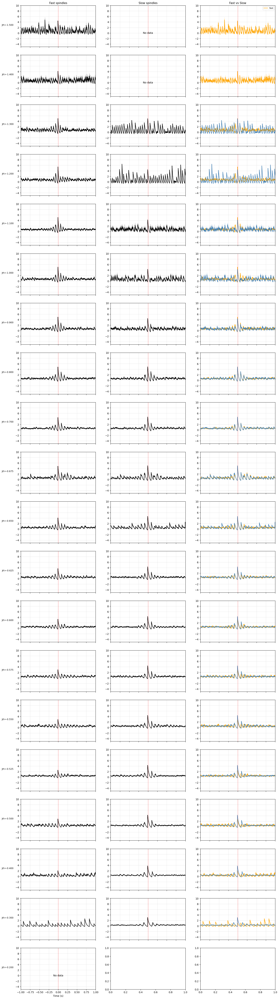

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000
window_before = 1.0
window_after = 1.0
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"

# ========== 2. 读取 CSV ==========
df_spindles = pd.read_csv(CSV_PATH)
print(f"读取 {len(df_spindles)} 个纺锤波")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

Jrt_values = sorted(df_spindles['Jrt'].unique())
Jrt_groups = {}
for Jrt_val in Jrt_values:
    Jrt_groups[Jrt_val] = {"fast": [], "slow": []}

for _, row in df_spindles.iterrows():
    Jrt_val = row["Jrt"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (Jrt_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        Jrt_groups[Jrt_val][spindle_type].append(seg)

# ========== 5. 计算均值和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

print("\n各 Jrt 值纺锤波数量:")
for Jrt_val in Jrt_values:
    fast_count = len(Jrt_groups[Jrt_val]["fast"])
    slow_count = len(Jrt_groups[Jrt_val]["slow"])
    print(f"  Jrt={Jrt_val:.3f}: fast={fast_count}, slow={slow_count}")

# ========== 6. 所有 Jrt 值画在一张大图里 ==========
n_Jrt = len(Jrt_values)
fig, axes = plt.subplots(n_Jrt, 3, figsize=(18, 3.5 * n_Jrt))

if n_Jrt == 1:
    axes = axes.reshape(1, -1)

for row_idx, Jrt_val in enumerate(Jrt_values):
    fast_segs = Jrt_groups[Jrt_val]["fast"]
    slow_segs = Jrt_groups[Jrt_val]["slow"]
    
    fast_mean, fast_sem = compute_mean_sem(fast_segs)
    slow_mean, slow_sem = compute_mean_sem(slow_segs)
    
    # 列1：快纺锤波
    ax = axes[row_idx, 0]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='black', alpha=0.2)
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=9, rotation=0, labelpad=30)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=9, rotation=0, labelpad=30)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Fast spindles', fontsize=11)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)
    
    # 列2：慢纺锤波
    ax = axes[row_idx, 1]
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='black', alpha=0.2)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Slow spindles', fontsize=11)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)
    
    # 列3：快慢叠加
    ax = axes[row_idx, 2]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'orange', linewidth=1.5, label='Fast')
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='orange', alpha=0.2)
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'steelblue', linewidth=1.5, label='Slow')
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='steelblue', alpha=0.2)
    if fast_mean is None and slow_mean is None:
        ax.text(0, 0, 'No data', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Fast vs Slow', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)

plt.suptitle(f'TC Neuron Activity (V_t) - a=8.4, Jrt Scan', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

读取 1929 个纺锤波
Jrt 值: [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.675, -0.65, -0.625, -0.6, -0.575, -0.55, -0.525, -0.5]
找到 170 个匹配的文件

处理 Jrt=-1.5000
  纺锤波总数: 11
  快纺锤波: 11
  慢纺锤波: 0
  快片段: 7, 慢片段: 0

处理 Jrt=-1.4000
  纺锤波总数: 5
  快纺锤波: 5
  慢纺锤波: 0
  快片段: 5, 慢片段: 0

处理 Jrt=-1.3000
  纺锤波总数: 60
  快纺锤波: 59
  慢纺锤波: 1
  快片段: 53, 慢片段: 1

处理 Jrt=-1.2000
  纺锤波总数: 78
  快纺锤波: 77
  慢纺锤波: 1
  快片段: 70, 慢片段: 1

处理 Jrt=-1.1000
  纺锤波总数: 101
  快纺锤波: 96
  慢纺锤波: 5
  快片段: 89, 慢片段: 5

处理 Jrt=-1.0000
  纺锤波总数: 93
  快纺锤波: 85
  慢纺锤波: 8
  快片段: 78, 慢片段: 8

处理 Jrt=-0.9000
  纺锤波总数: 104
  快纺锤波: 86
  慢纺锤波: 18
  快片段: 75, 慢片段: 14

处理 Jrt=-0.8000
  纺锤波总数: 130
  快纺锤波: 67
  慢纺锤波: 63
  快片段: 61, 慢片段: 57

处理 Jrt=-0.7000
  纺锤波总数: 158
  快纺锤波: 78
  慢纺锤波: 80
  快片段: 73, 慢片段: 74

处理 Jrt=-0.6750
  纺锤波总数: 159
  快纺锤波: 66
  慢纺锤波: 93
  快片段: 61, 慢片段: 87

处理 Jrt=-0.6500
  纺锤波总数: 141
  快纺锤波: 55
  慢纺锤波: 86
  快片段: 48, 慢片段: 77

处理 Jrt=-0.6250
  纺锤波总数: 156
  快纺锤波: 67
  慢纺锤波: 89
  快片段: 61, 慢片段: 79

处理 Jrt=-0.6000
  纺锤波总数: 140
  快纺锤

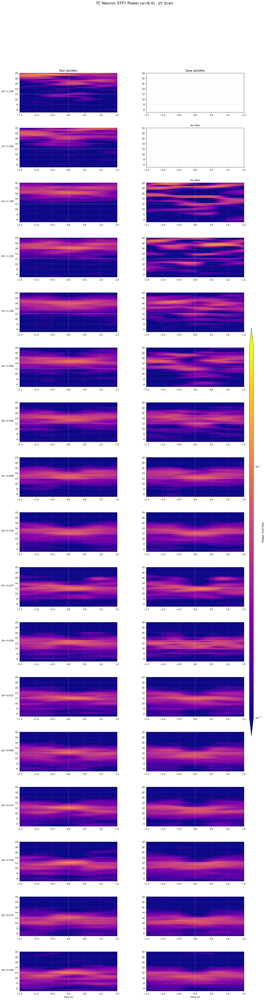

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import yasa
from yasa import stft_power
import matplotlib as mpl
import seaborn as sns

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
window_before = 1.5
window_after = 1.5
window_samples = int((window_before + window_after) * sf)

TARGET_A = 8.4
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"
CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"

# STFT 参数
window = 2.0   # 秒
step = 0.2     # 秒
freqs_bounds = (0.5, 30.0)
vmin = 0.01
vmax = 0.3
CMAP = "plasma"
SXX_EPS = 1.1e-3

# ========== 2. 读取 CSV ==========
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

Jrt_values = sorted(df['Jrt'].unique())
print(f"Jrt 值: {Jrt_values}")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path
print(f"找到 {len(file_map)} 个匹配的文件")

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

# ========== 5. 计算平均 STFT 功率 ==========
def compute_average_stft(segments, sf, window, step, freqs_bounds):
    if len(segments) == 0:
        return None, None, None
    
    all_power = []
    common_f = None
    common_t = None
    
    for seg in segments:
        t_axis = np.linspace(-window_before, window_after, len(seg))
        seg_series = pd.Series(seg, index=t_axis)
        
        f, t, Sxx = stft_power(
            seg_series,
            sf,
            window=window,
            step=step,
            band=freqs_bounds,
            norm=True,
            interp=True,
        )
        
        t_aligned = t - window_before
        
        if common_f is None:
            common_f = f
            common_t = t_aligned
        
        all_power.append(Sxx)
    
    if len(all_power) == 0:
        return None, None, None
    
    min_t_len = min([p.shape[1] for p in all_power])
    all_power_cropped = [p[:, :min_t_len] for p in all_power]
    
    all_power_array = np.array(all_power_cropped)
    mean_power = np.mean(all_power_array, axis=0)
    
    t_axis = common_t[:min_t_len]
    
    return common_f, t_axis, mean_power

# ========== 6. 对每个 Jrt 值计算 STFT ==========
Jrt_data = {}

for Jrt_val in Jrt_values:
    print(f"\n处理 Jrt={Jrt_val:.4f}")
    
    df_filtered = df[df['Jrt'] == Jrt_val].copy()
    print(f"  纺锤波总数: {len(df_filtered)}")
    print(f"  快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
    print(f"  慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")
    
    if len(df_filtered) == 0:
        Jrt_data[Jrt_val] = {'fast': (None, None, None, 0), 'slow': (None, None, None, 0)}
        continue
    
    fast_segments = []
    slow_segments = []
    
    for _, row in df_filtered.iterrows():
        Jrt_val_row = row["Jrt"]
        seed = row["seed"]
        peak_time = row["peak"]
        spindle_type = row["type"]
        
        key = (Jrt_val_row, seed)
        if key not in file_map:
            continue
        
        seg = extract_segment(file_map[key], peak_time, sf, window_samples)
        if seg is not None:
            if spindle_type == 'fast':
                fast_segments.append(seg)
            else:
                slow_segments.append(seg)
    
    print(f"  快片段: {len(fast_segments)}, 慢片段: {len(slow_segments)}")
    
    fast_f, fast_t, fast_power = compute_average_stft(fast_segments, sf, window, step, freqs_bounds)
    slow_f, slow_t, slow_power = compute_average_stft(slow_segments, sf, window, step, freqs_bounds)
    
    Jrt_data[Jrt_val] = {
        'fast': (fast_f, fast_t, fast_power, len(fast_segments)),
        'slow': (slow_f, slow_t, slow_power, len(slow_segments))
    }

# ========== 7. 所有 Jrt 值画在一张大图里 ==========
n_Jrt = len(Jrt_values)
fig = plt.figure(figsize=(16, 3.5 * n_Jrt))
gs = fig.add_gridspec(nrows=n_Jrt, ncols=2)
gs.update(wspace=0.3, hspace=0.4)

# 记录第一个有效的 im 用于颜色条
first_im = None

for row_idx, Jrt_val in enumerate(Jrt_values):
    fast_f, fast_t, fast_power, fast_n = Jrt_data[Jrt_val]['fast']
    slow_f, slow_t, slow_power, slow_n = Jrt_data[Jrt_val]['slow']
    
    # 左图：快纺锤波
    ax = fig.add_subplot(gs[row_idx, 0])
    if fast_power is not None and fast_power.size > 0:
        im = ax.pcolormesh(
            fast_t,
            fast_f,
            fast_power + SXX_EPS,
            cmap=CMAP,
            rasterized=True,
            norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
        )
        if first_im is None:
            first_im = im
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=10, rotation=0, labelpad=30)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=10, rotation=0, labelpad=30)
    
    # 添加 12 Hz 分界线（白色虚线）
    ax.axhline(y=12, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(5, 20)
    ax.grid(True, alpha=0.2)
    if row_idx == 0:
        ax.set_title('Fast spindles', fontsize=12)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    
    # 右图：慢纺锤波
    ax = fig.add_subplot(gs[row_idx, 1])
    if slow_power is not None and slow_power.size > 0:
        im = ax.pcolormesh(
            slow_t,
            slow_f,
            slow_power + SXX_EPS,
            cmap=CMAP,
            rasterized=True,
            norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
        )
        if first_im is None:
            first_im = im
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
    
    # 添加 12 Hz 分界线（白色虚线）
    ax.axhline(y=12, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(5, 20)
    ax.grid(True, alpha=0.2)
    if row_idx == 0:
        ax.set_title('Slow spindles', fontsize=12)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax,
    cmap=plt.get_cmap(CMAP),
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    orientation="vertical",
    extend="both",
)
cbar.set_label("Power (mV²/Hz)", fontsize=11)

plt.suptitle(f'TC Neuron STFT Power (a={TARGET_A}) - Jrt Scan', fontsize=16, y=1.02)

# 不使用 tight_layout，改用 subplots_adjust
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.08, right=0.90)
plt.show()